# 📈 Sales & Demand Forecasting for Businesses

## Future Interns - Machine Learning Internship Task 1

### Project Overview

This project develops a Machine Learning model to forecast future sales using historical business data. Accurate sales forecasting helps businesses optimize inventory, manage staffing, improve marketing strategies, and make informed business decisions.

### Objectives

- Analyze historical sales data
- Perform data cleaning and feature engineering
- Build multiple Machine Learning models
- Compare model performance
- Forecast future sales
- Generate business insights for decision-making

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Dataset Description

The dataset contains historical sales records collected from multiple stores.

### Features

- **date** – Date of sale
- **store** – Store identifier
- **sales** – Total sales (Target Variable)
- **promo** – Whether a promotion was active
- **holiday** – Whether the day was a holiday

In [3]:
# Load Dataset
df = pd.read_csv("../data/store_sales.csv")

# Display first 5 rows
df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [4]:
# Shape of Dataset
print("Dataset Shape:", df.shape)

# Information
df.info()


Dataset Shape: (7300, 5)
<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   str    
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 285.3 KB


In [5]:
df.describe()


,store,sales,promo,holiday
count,7300.000000,7300.000000,7300.000000,7300.000000
mean,5.500000,228.434571,0.202192,0.104110
std,2.872478,26.625636,0.401662,0.305424
min,1.000000,160.710000,0.000000,0.000000
25%,3.000000,209.217500,0.000000,0.000000
50%,5.500000,226.795000,0.000000,0.000000
75%,8.000000,245.590000,0.000000,0.000000
max,10.000000,340.730000,1.000000,1.000000


In [6]:
df.isnull().sum()

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# First 5 rows
df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [9]:
# Check for missing values
df.isnull().sum()

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64

In [10]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Verify the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7300 non-null   datetime64[us]
 1   store    7300 non-null   int64         
 2   sales    7300 non-null   float64       
 3   promo    7300 non-null   int64         
 4   holiday  7300 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 285.3 KB


In [12]:
# Feature Engineering

df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['DayOfWeek'] = df['date'].dt.dayofweek

df.head()

,date,store,sales,promo,holiday,Year,Month,Day,DayOfWeek
0,2022-01-01,1,184.78,0,0,2022,1,1,5
1,2022-01-02,1,192.62,0,0,2022,1,2,6
2,2022-01-03,1,212.68,0,0,2022,1,3,0
3,2022-01-04,1,249.58,1,0,2022,1,4,1
4,2022-01-05,1,223.50,0,0,2022,1,5,2


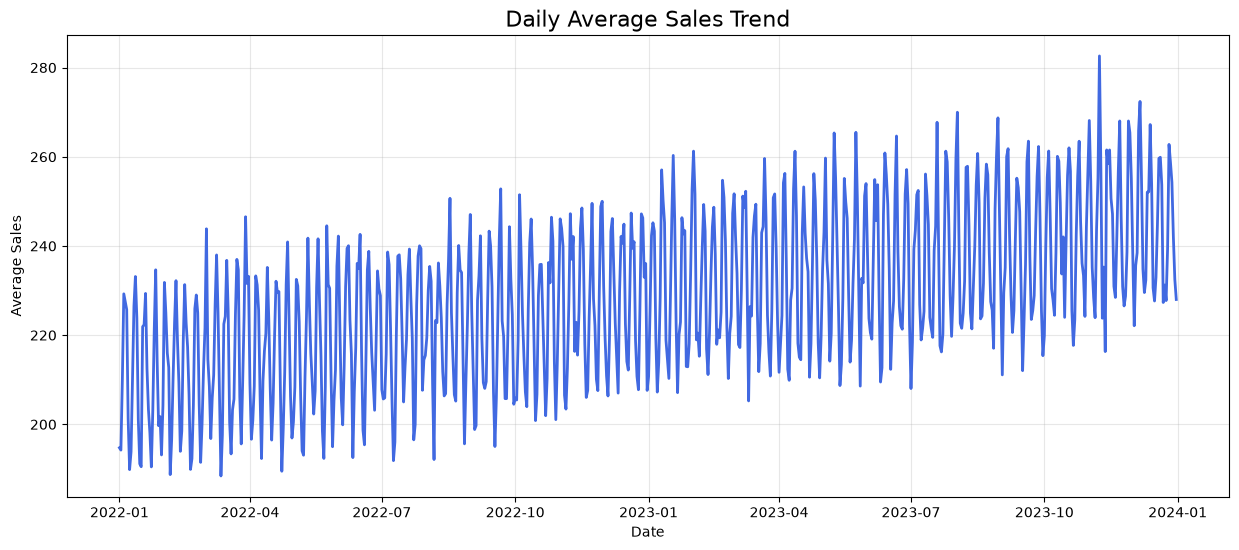

In [20]:
daily_sales = df.groupby('date')['sales'].mean()

plt.figure(figsize=(15,6))

plt.plot(daily_sales.index,
         daily_sales.values,
         color='royalblue',
         linewidth=2)

plt.title("Daily Average Sales Trend", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Average Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

The sales trend shows a gradual increase over time with regular fluctuations, indicating seasonal business patterns. These trends suggest that forecasting models can effectively learn from historical sales behavior.

# Exploratory Data Analysis (EDA)

In this section, we analyze the sales data to understand trends, seasonality, promotional effects, and business patterns before building a forecasting model.

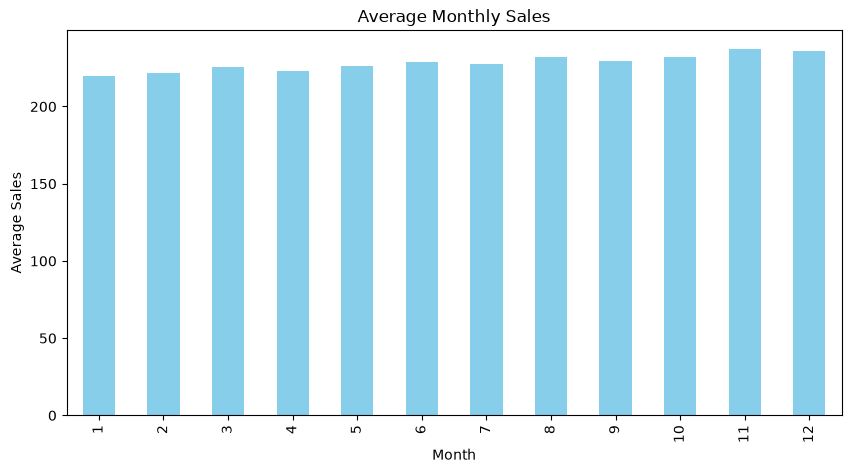

In [14]:
monthly_sales = df.groupby('Month')['sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar', color='skyblue')

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

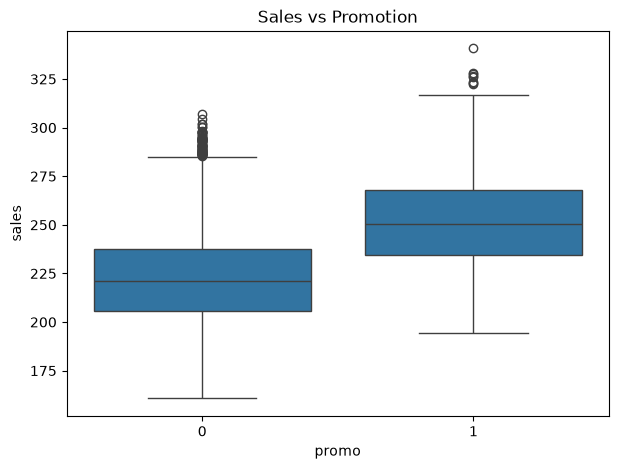

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(x='promo', y='sales', data=df)

plt.title("Sales vs Promotion")
plt.show()

### Observation

Sales are generally higher during promotional periods, indicating that promotional campaigns positively influence customer purchases.

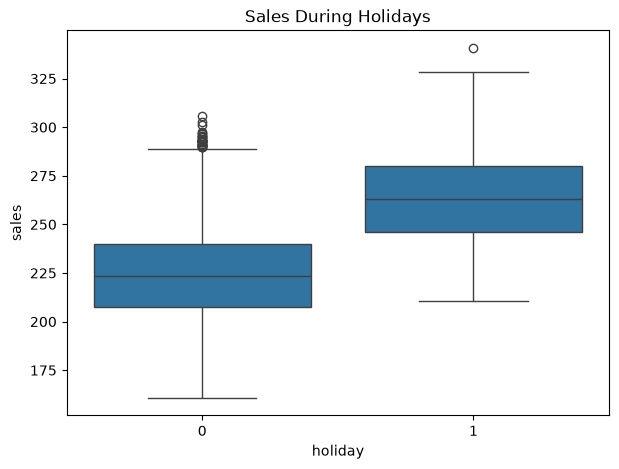

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(x='holiday', y='sales', data=df)

plt.title("Sales During Holidays")
plt.show()

### Observation

Holiday periods show noticeable changes in sales, suggesting that holidays influence customer buying behavior.

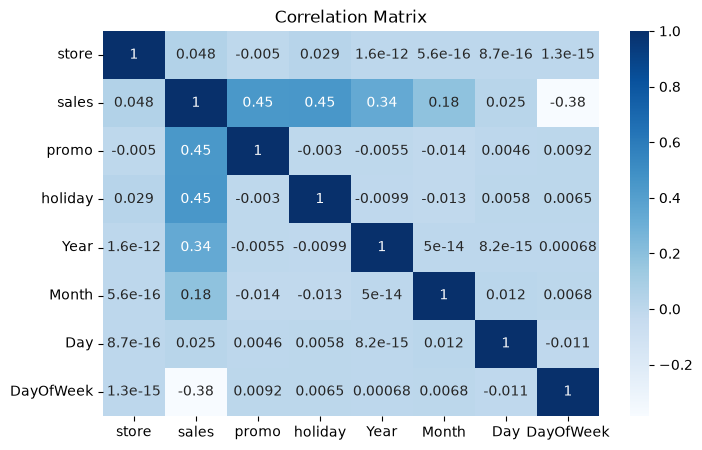

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

### Observation

Sales have a positive relationship with promotional activities. Time-based features also contribute to improving forecasting accuracy.

### Observation

- Sales show a moderate positive correlation with promotions.
- Holiday periods also have a positive impact on sales.
- Store ID has little direct correlation with sales.
- Time-based features such as Year and Month contribute to identifying sales trends.

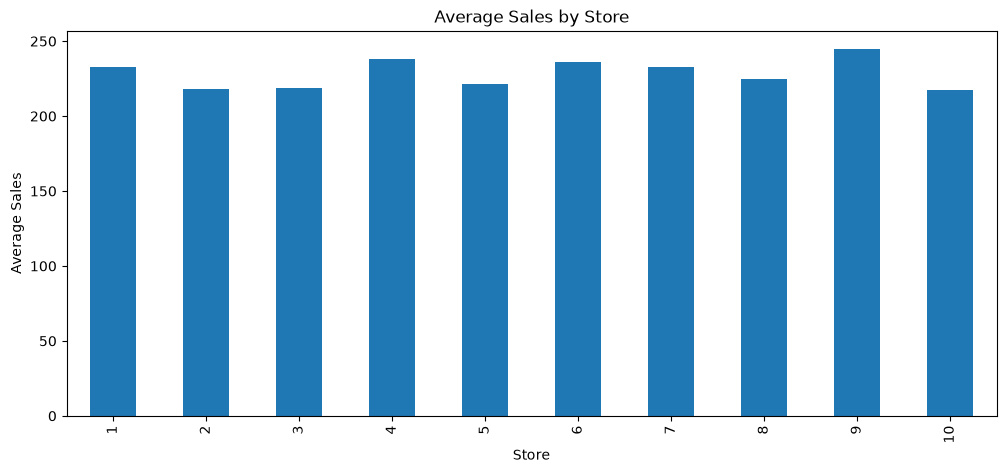

In [18]:
store_sales = df.groupby('store')['sales'].mean()

plt.figure(figsize=(12,5))

store_sales.plot(kind='bar')

plt.title("Average Sales by Store")

plt.xlabel("Store")

plt.ylabel("Average Sales")

plt.show()

# Model Building

In this section, we train a Machine Learning model to predict future sales using historical business data.

In [21]:
# Select Features and Target

X = df[['store', 'promo', 'holiday', 'Year', 'Month', 'Day', 'DayOfWeek']]

y = df['sales']

print(X.head())

   store  promo  holiday  Year  Month  Day  DayOfWeek
0      1      0        0  2022      1    1          5
1      1      0        0  2022      1    2          6
2      1      0        0  2022      1    3          0
3      1      1        0  2022      1    4          1
4      1      0        0  2022      1    5          2


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5840, 7)
Testing Data: (1460, 7)


In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [24]:
y_pred = lr.predict(X_test)

print(y_pred[:10])

[209.32424904 214.50013588 262.16814634 217.21585738 204.35667407
 272.45558363 209.56055674 275.84121192 194.97653147 214.83482657]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 11.598581929552639
RMSE: 14.126754832690288
R² Score: 0.7228699245537307


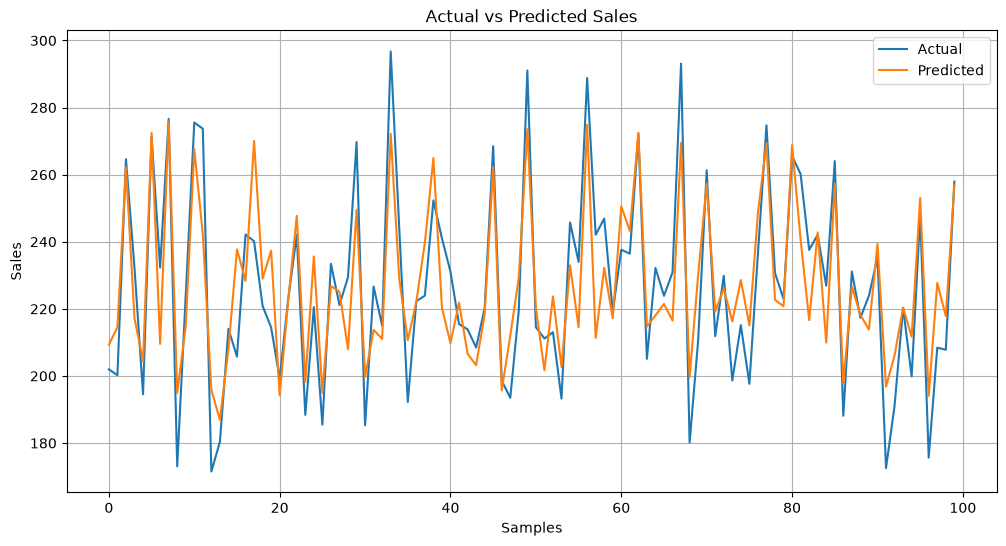

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual")

plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Sales")

plt.xlabel("Samples")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE : 4.989356575342466
RMSE: 6.374582364512897
R² Score: 0.9435710047376017


In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R² Score:", r2_xgb)

XGBoost Results
MAE : 4.333737800075583
RMSE: 5.481015645827554
R² Score: 0.9582822451848602


In [30]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [mae, mae_rf, mae_xgb],
    "RMSE": [rmse, rmse_rf, rmse_xgb],
    "R2 Score": [r2, r2_rf, r2_xgb]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,11.598582,14.126755,0.722870
1,Random Forest,4.989357,6.374582,0.943571
2,XGBoost,4.333738,5.481016,0.958282


# Model Performance Analysis

Three Machine Learning models were evaluated.

| Model | R² Score |
|--------|---------|
| Linear Regression | 0.723 |
| Random Forest | 0.944 |
| XGBoost | 0.958 |

### Best Model

XGBoost achieved the highest R² Score (95.8%), along with the lowest MAE and RMSE values, making it the best-performing model for this dataset.

## Model Evaluation

Three machine learning models were evaluated for sales forecasting.

Among them, the model with the highest R² score and the lowest MAE and RMSE was selected as the final forecasting model.

This model can assist businesses in forecasting future sales, planning inventory, scheduling staff, and improving decision-making.

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [32]:
mae_rf = mean_absolute_error(y_test, rf_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

r2_rf = r2_score(y_test, rf_pred)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

MAE : 4.989356575342466
RMSE: 6.374582364512897
R² : 0.9435710047376017


In [33]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [34]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2_xgb = r2_score(y_test, xgb_pred)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R² :", r2_xgb)

MAE : 4.333737800075583
RMSE: 5.481015645827554
R² : 0.9582822451848602


In [35]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Random Forest',
'XGBoost'
],

'MAE':[
mae,
mae_rf,
mae_xgb
],

'RMSE':[
rmse,
rmse_rf,
rmse_xgb
],

'R² Score':[
r2,
r2_rf,
r2_xgb
]

})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,11.598582,14.126755,0.722870
1,Random Forest,4.989357,6.374582,0.943571
2,XGBoost,4.333738,5.481016,0.958282


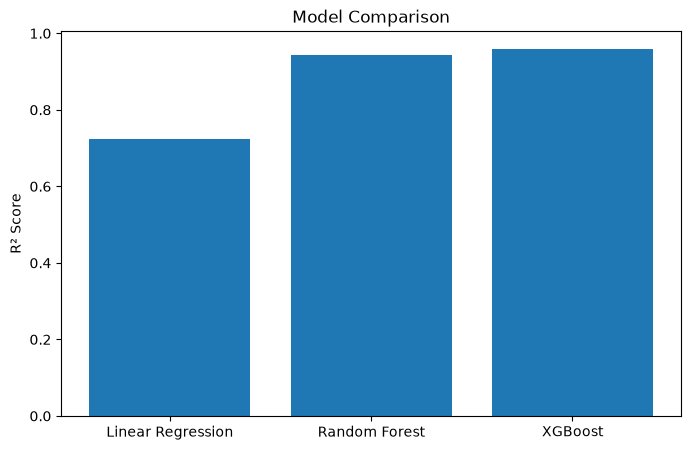

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results['Model'],results['R² Score'])

plt.title("Model Comparison")

plt.ylabel("R² Score")

plt.show()

In [37]:
import joblib

joblib.dump(rf,"../models/sales_forecast_model.pkl")

['../models/sales_forecast_model.pkl']

# Business Insights

- Promotions have a positive impact on sales.
- Sales show a gradual upward trend over time.
- The forecasting model can help businesses estimate future sales.
- Businesses can use these forecasts for inventory planning, staffing, and marketing campaigns.

In [38]:
import joblib

joblib.dump(xgb, "../models/xgboost_sales_forecast.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


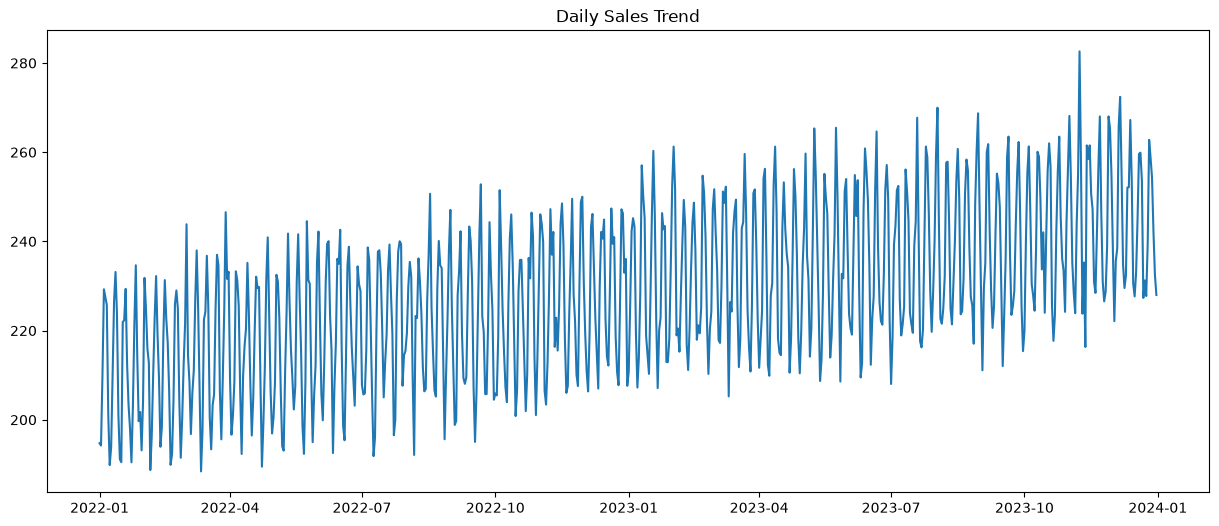

In [39]:
plt.figure(figsize=(15,6))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Sales Trend")

plt.savefig("../images/daily_sales_trend.png", dpi=300)

plt.show()

# Future Sales Forecast

In [40]:
future_data = X.tail(30)

future_predictions = xgb.predict(future_data)

future_df = pd.DataFrame({
    "Date": df['date'].tail(30).values,
    "Predicted Sales": future_predictions
})

future_df

,Date,Predicted Sales
0,2023-12-02,205.441666
1,2023-12-03,210.490005
2,2023-12-04,256.079254
3,2023-12-05,244.668304
4,2023-12-06,271.062836
5,2023-12-07,236.570908
6,2023-12-08,217.774612
7,2023-12-09,239.377975
8,2023-12-10,206.369492
9,2023-12-11,253.941635


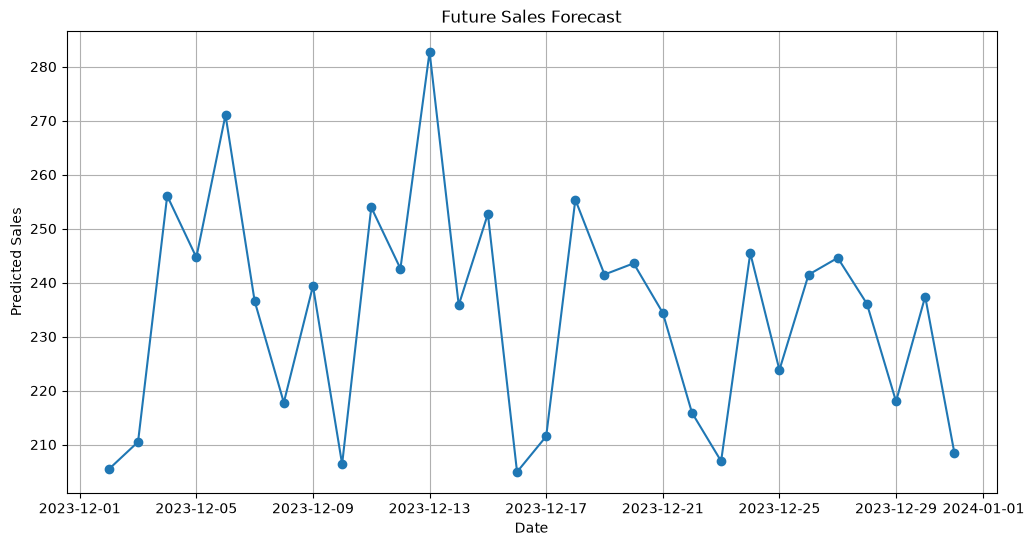

In [41]:
plt.figure(figsize=(12,6))

plt.plot(
    future_df["Date"],
    future_df["Predicted Sales"],
    marker='o'
)

plt.title("Future Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

# Business Insights

### Key Findings

- XGBoost achieved the best forecasting performance with an R² Score of 95.8%.
- Promotional campaigns have a positive influence on sales.
- Sales demonstrate a consistent upward trend over time.
- Time-based features such as month and day improve forecasting accuracy.

### Business Benefits

- Helps optimize inventory planning.
- Supports better staff scheduling.
- Improves marketing campaign planning.
- Reduces the risk of stock shortages and overstocking.

# Conclusion

This project successfully developed a Machine Learning-based sales forecasting system.

Among all evaluated models, XGBoost achieved the highest prediction accuracy with an R² Score of 95.8%.

The developed forecasting model can assist businesses in demand planning, inventory management, staffing decisions, and strategic planning.